# Spam Emails Classification
___
By Abdullah

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import text_to_word_sequence
from tensorflow.keras.preprocessing.text import Tokenizer


from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import metrics
from tensorflow.keras import optimizers

In [2]:
## ====> Libraries for Preprocessing
import re
import string
import nltk
nltk.download('all')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import unicodedata
import html
stop_words = stopwords.words('english')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

## Reading Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/NLP/Projects/Spam Classification/emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


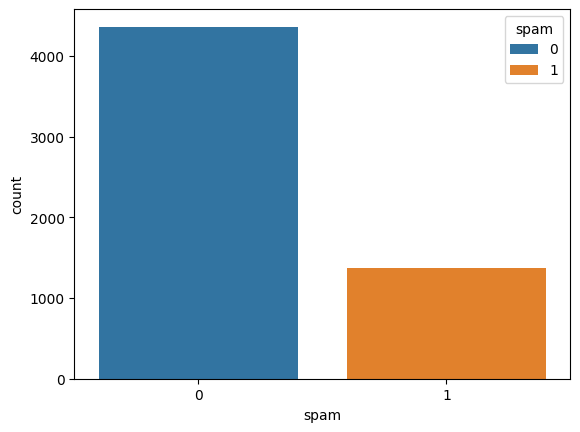

In [5]:
sns.countplot(x = df["spam"],hue=df["spam"])
plt.show()

In [6]:
text = df['text'].values

In [7]:
for t in text[:10]:
  print(t, end='\n\n')

Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  mar

## Preprocessing

In [8]:
def remove_special_chars(text):
    re1 = re.compile(r'  +')
    x1 = text.lower().replace('#39;', "'").replace('amp;', '&').replace('#146;', "'").replace(
        'nbsp;', ' ').replace('#36;', '$').replace('\\n', "\n").replace('quot;', "'").replace(
        '<br />', "\n").replace('\\"', '"').replace('<unk>', 'u_n').replace(' @.@ ', '.').replace(
        ' @-@ ', '-').replace('\\', ' \\ ')
    return re1.sub(' ', html.unescape(x1))


def remove_non_ascii(text):
    """Remove non-ASCII characters from list of tokenized words"""
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')


def to_lowercase(text):
    return text.lower()



def remove_punctuation(text):
    """Remove punctuation from list of tokenized words"""
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)


def replace_numbers(text):
    """Replace all interger occurrences in list of tokenized words with textual representation"""
    return re.sub(r'\d+', '', text)


def remove_whitespaces(text):
    return text.strip()


def remove_stopwords(words, stop_words):
    """
    :param words:
    :type words:
    :param stop_words: from sklearn.feature_extraction.stop_words import ENGLISH_STOP_WORDS
    or
    from spacy.lang.en.stop_words import STOP_WORDS
    :type stop_words:
    :return:
    :rtype:
    """
    return [word for word in words if word not in stop_words]


# def stem_words(words):
#     """Stem words in text"""
#     stemmer = PorterStemmer()
#     return [stemmer.stem(word) for word in words]

def lemmatize_words(words):
    """Lemmatize words in text"""

    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in words]

def lemmatize_verbs(words):
    """Lemmatize verbs in text"""

    lemmatizer = WordNetLemmatizer()
    return ' '.join([lemmatizer.lemmatize(word, pos='v') for word in words])

def text2words(text):
  return word_tokenize(text)

def normalize_text( text):
    text = remove_special_chars(text)
    text = remove_non_ascii(text)
    text = remove_punctuation(text)
    text = to_lowercase(text)
    text = replace_numbers(text)
    words = text2words(text)
    words = remove_stopwords(words, stop_words)
    words = lemmatize_words(words)
    words = lemmatize_verbs(words)

    return ''.join(words)

In [9]:
def normalize_corpus(corpus):
  return [normalize_text(t) for t in corpus]
texts = normalize_corpus(text)

In [10]:
for t in texts[:10]:
  print(t,end='\n\n')

subject naturally irresistible corporate identity lt really hard recollect company market full suqgestions information isoverwhelminq good catchy logo stylish statlonery outstanding website make task much easier promise havinq order iogo company automaticaily become world ieader isguite ciear without good product effective business organization practicable aim hotat nowadays market promise market effort become much effective list clear benefit creativeness hand make original logo specially do reflect distinctive company image convenience logo stationery provide format easy use content management system letsyou change website content even structure promptness see logo draft within three business day affordability market break make gap budget satisfaction guarantee provide unlimited amount change extra fee surethat love result collaboration look portfolio interest

subject stock trade gunslinger fanny merrill muzo colza attainder penultimate like esmark perspicuous ramble segovia group t

## Splitting

In [11]:
from sklearn.model_selection import train_test_split
y = df['spam'].values

def splitting(X):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)
  return X_train, X_test, y_train, y_test


## Model

In [12]:

from tensorflow.keras.optimizers import AdamW
def ann_model(X_train, X_test, y_train, y_test, epoch=10):
  model = models.Sequential()

  model.add(layers.Dense(30, activation='relu')) # model.add(layers.Dense(32, activation='leaky_relu'))
  model.add(layers.Dense(1, activation='sigmoid'))
  model.summary()
  model.compile(
      optimizer=AdamW(learning_rate=0.001, weight_decay=0.004),
      # optimizer='adam',
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])
  history = model.fit(X_train,
                    y_train,
                    epochs=epoch,
                    batch_size=256,
                    validation_data=(X_test, y_test))
  return history

In [13]:
def result_plot(history):
  history_dict = history.history

  acc = history_dict['binary_accuracy']
  val_acc = history_dict['val_binary_accuracy']
  loss = history_dict['loss']
  val_loss = history_dict['val_loss']
  epochs = range(1, len(acc) + 1)
  plt.clf()

  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)


  ax1.plot(epochs, acc, 'bo', label='Training acc')
  ax1.plot(epochs, val_acc, 'b', label='Validation acc')
  ax1.set_title('Training and Validation Accuracy')
  ax1.set_ylabel('Accuracy')  # Corrected from 'Loss' to 'Accuracy'
  ax1.legend()
  ax1.grid(True)


  ax2.plot(epochs, loss, 'bo', label='Training loss')
  ax2.plot(epochs, val_loss, 'b', label='Validation loss')
  ax2.set_title('Training and Validation Loss')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Loss')
  ax2.legend()
  ax2.grid(True)

  plt.tight_layout()
  plt.show()

## Use the diff ways to Representation using Tensoflow & Keras

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
tok = Tokenizer(oov_token='UNK')
tok.fit_on_texts(texts)

In [15]:
len(tok.word_index)

28150

### 1. Count

In [16]:
bow1 = tok.texts_to_matrix(texts , mode='count')
bow1[9]

array([0., 0., 0., ..., 0., 0., 0.])

In [17]:
X_train_count, X_test_count, y_train_count, y_test_count = splitting(bow1)

In [49]:
history_count = ann_model(X_train_count, X_test_count, y_train_count, y_test_count,5)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - binary_accuracy: 0.8180 - loss: 0.4600 - val_binary_accuracy: 0.9834 - val_loss: 0.1716
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - binary_accuracy: 0.9939 - loss: 0.1327 - val_binary_accuracy: 0.9869 - val_loss: 0.0924
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - binary_accuracy: 0.9970 - loss: 0.0686 - val_binary_accuracy: 0.9913 - val_loss: 0.0682
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - binary_accuracy: 0.9989 - loss: 0.0477 - val_binary_accuracy: 0.9904 - val_loss: 0.0565
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - binary_accuracy: 0.9995 - loss: 0.0315 - val_binary_accuracy: 0.9904 - val_loss: 0.0496


<Figure size 640x480 with 0 Axes>

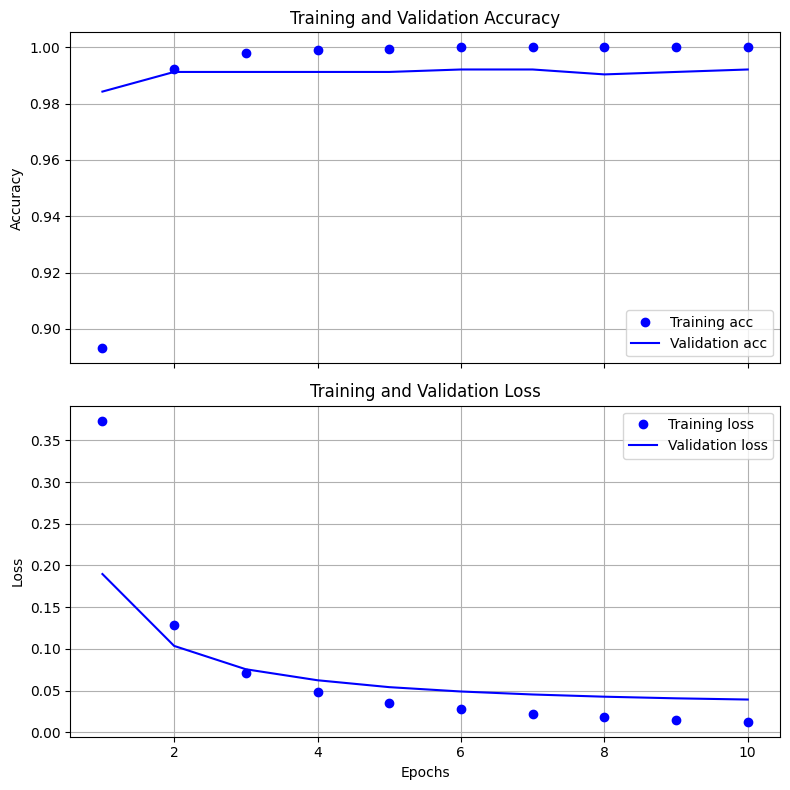

In [19]:
result_plot(history_count)

___
$$****************************$$
___

### Freq

In [20]:
bow2 = tok.texts_to_matrix(texts , mode='freq')
bow2[9]

array([0., 0., 0., ..., 0., 0., 0.])

In [21]:
X_train_freq, X_test_freq, y_train_freq, y_test_freq = splitting(bow2)

In [22]:
history_freq = ann_model(X_train_freq, X_test_freq, y_train_freq, y_test_freq,35)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - binary_accuracy: 0.7107 - loss: 0.6839 - val_binary_accuracy: 0.7670 - val_loss: 0.6540
Epoch 2/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - binary_accuracy: 0.7594 - loss: 0.6433 - val_binary_accuracy: 0.7670 - val_loss: 0.6112
Epoch 3/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - binary_accuracy: 0.7655 - loss: 0.5979 - val_binary_accuracy: 0.7670 - val_loss: 0.5667
Epoch 4/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - binary_accuracy: 0.7482 - loss: 0.5566 - val_binary_accuracy: 0.7696 - val_loss: 0.5234
Epoch 5/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - binary_accuracy: 0.7692 - loss: 0.5082 - val_binary_accuracy: 0.7853 - val_loss: 0.4825
Epoch 6/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - binary_accuracy: 0.7935 - loss: 0.4622 - val_binary_accuracy: 0.7958 - val_loss: 0.4450
Epoch 7/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - binary_accuracy: 0.7948 - loss: 0.4276 - val_binary_accuracy: 0.8072 - val_loss: 0.4105
Epoch 8/35


<Figure size 640x480 with 0 Axes>

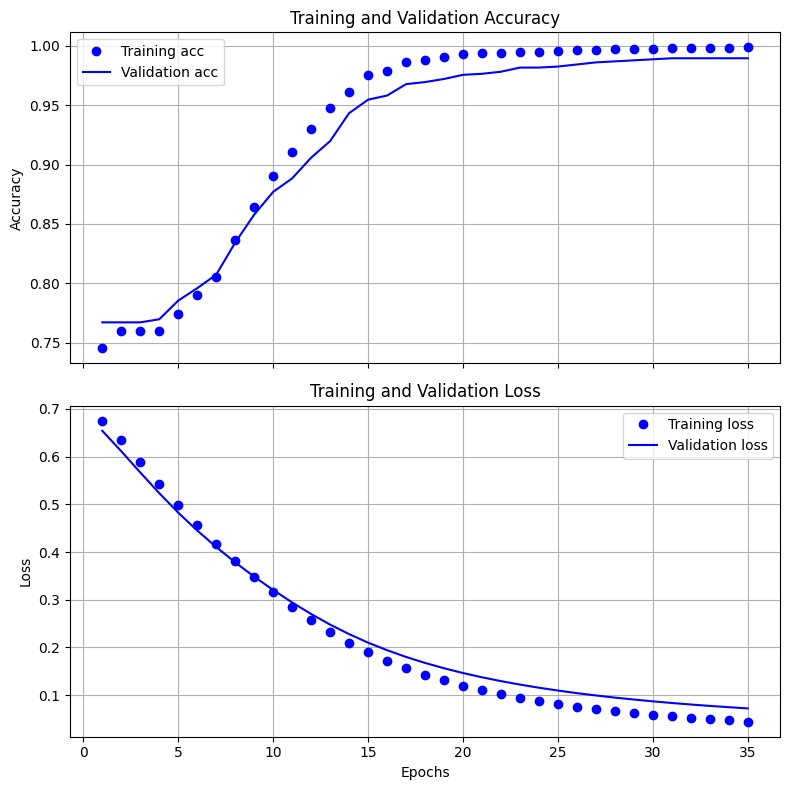

In [23]:
result_plot(history_freq)

___
$$****************************$$
___

### TFIDF

In [24]:
bow3 = tok.texts_to_matrix(texts , mode='tfidf')
bow3[9]

array([0., 0., 0., ..., 0., 0., 0.])

In [25]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = splitting(bow3)

In [26]:
history_tfidf= ann_model(X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf,12)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - binary_accuracy: 0.8184 - loss: 0.3989 - val_binary_accuracy: 0.9860 - val_loss: 0.0852
Epoch 2/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - binary_accuracy: 0.9987 - loss: 0.0449 - val_binary_accuracy: 0.9887 - val_loss: 0.0480
Epoch 3/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - binary_accuracy: 0.9999 - loss: 0.0157 - val_binary_accuracy: 0.9895 - val_loss: 0.0406
Epoch 4/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - binary_accuracy: 1.0000 - loss: 0.0102 - val_binary_accuracy: 0.9895 - val_loss: 0.0379
Epoch 5/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - binary_accuracy: 1.0000 - loss: 0.0077 - val_binary_accuracy: 0.9895 - val_loss: 0.0366
Epoch 6/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - binary_accuracy: 1.0000 - loss: 0.0058 - val_binary_accuracy: 0.9895 - val_loss: 0.0359
Epoch 7/12
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - binary_accuracy: 1.0000 - loss: 0.0055 - val_binary_accuracy: 0.9895 - val_loss: 0.0353
Epoch 8/12


<Figure size 640x480 with 0 Axes>

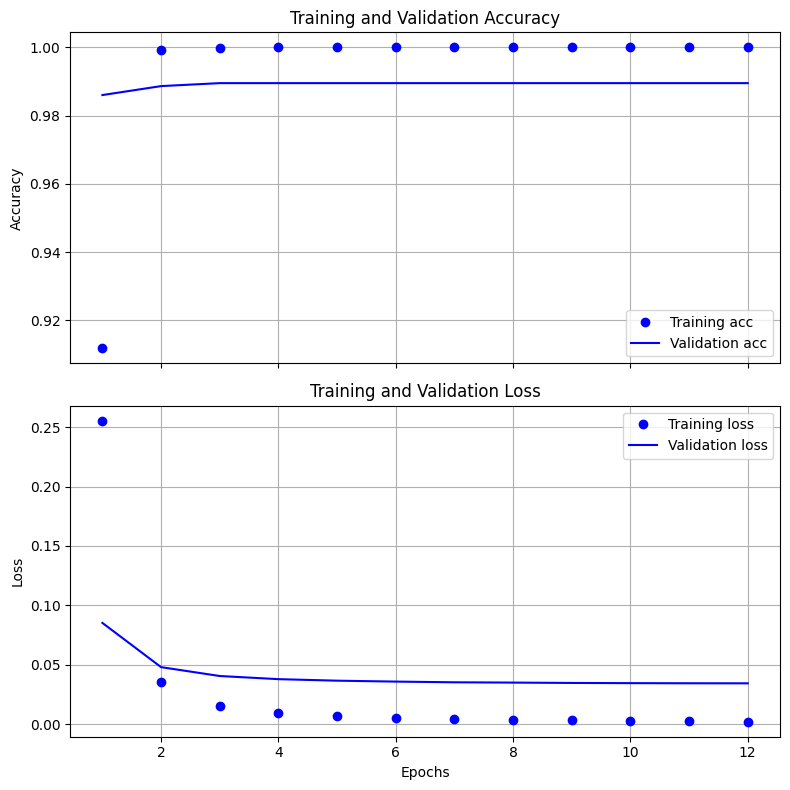

In [27]:
result_plot(history_tfidf)

___
$$****************************$$
___

## We observed no significant differences between the three text representation methods—Count, Frequency, and TF-IDF—in our current problem. However, in other problems or datasets, these methods may yield more noticeable variations in performance. for exapmle: IMDB sentiment analysis project https://colab.research.google.com/drive/17Nnc27ShmESzAugslqa81YEUqadfTL7y

## Use LSTM & GRU models

In [28]:
from tensorflow.keras.layers import LSTM, GRU, Embedding, Dense, Dropout

In [50]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Assuming 'texts' is the preprocessed text column and 'labels' is the spam column
max_words = 10000  # Maximum number of words to consider (from Tokenizer)
max_len = 500      # Maximum sequence length for padding

# Tokenize texts
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])

# Pad sequences to ensure uniform length
X = pad_sequences(sequences, maxlen=max_len)
y = df['spam'].values

# Split into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
# Define LSTM Model
def build_lstm_model(max_words, max_len):
    model = models.Sequential()
    model.add(Embedding(max_words, 128, input_length=max_len))
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.8))
    model.add(Dense(18, activation='relu'))
    model.add(Dropout(0.6))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Build and train LSTM model
lstm_model = build_lstm_model(max_words, max_len)
lstm_model.summary()

# Train the model
history_lstm = lstm_model.fit(X_train, y_train,
                             epochs=10,
                             batch_size=64,
                             validation_data=(X_test, y_test),
                             verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 839ms/step - accuracy: 0.7018 - loss: 0.5934 - val_accuracy: 0.9450 - val_loss: 0.1947
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 83s 859ms/step - accuracy: 0.9512 - loss: 0.1838 - val_accuracy: 0.9738 - val_loss: 0.0862
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 818ms/step - accuracy: 0.9872 - loss: 0.0713 - val_accuracy: 0.9834 - val_loss: 0.0578
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 85s 868ms/step - accuracy: 0.9932 - loss: 0.0404 - val_accuracy: 0.9878 - val_loss: 0.0513
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 83s 882ms/step - accuracy: 0.9957 - loss: 0.0256 - val_accuracy: 0.9651 - val_loss: 0.1046
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 77s 803ms/step - accuracy: 0.9903 - loss: 0.0493 - val_accuracy: 0.9834 - val_loss: 0.0693
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 80s 777ms/step - accuracy: 0.9969 - loss: 0.0158 - val_accuracy: 0.9904 - val_loss: 0.0493
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 85s 816ms/step - accuracy: 0.9979 - loss: 0.0163 - val_accu

In [45]:
# Define GRU Model
def build_gru_model(max_words, max_len):
    model = models.Sequential()
    model.add(Embedding(max_words, 128, input_length=max_len))
    model.add(GRU(32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Build and train GRU model
gru_model = build_gru_model(max_words, max_len)
gru_model.summary()

# Train the model
history_gru = gru_model.fit(X_train, y_train,
                            epochs=10,
                            batch_size=64,
                            validation_data=(X_test, y_test),
                            verbose=1)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 207ms/step - accuracy: 0.7518 - loss: 0.5888 - val_accuracy: 0.9354 - val_loss: 0.1951
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 204ms/step - accuracy: 0.9628 - loss: 0.1237 - val_accuracy: 0.9599 - val_loss: 0.1235
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.9862 - loss: 0.0436 - val_accuracy: 0.9764 - val_loss: 0.0886
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step - accuracy: 0.9909 - loss: 0.0228 - val_accuracy: 0.9791 - val_loss: 0.0825
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 199ms/step - accuracy: 0.9882 - loss: 0.0265 - val_accuracy: 0.9686 - val_loss: 0.1179
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 198ms/step - accuracy: 0.9967 - loss: 0.0163 - val_accuracy: 0.9721 - val_loss: 0.1093
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 199ms/step - accuracy: 0.9992 - loss: 0.0101 - val_accuracy: 0.9712 - val_loss: 0.1406
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - accuracy: 0.9998 - loss: 0.0058 - val_accu

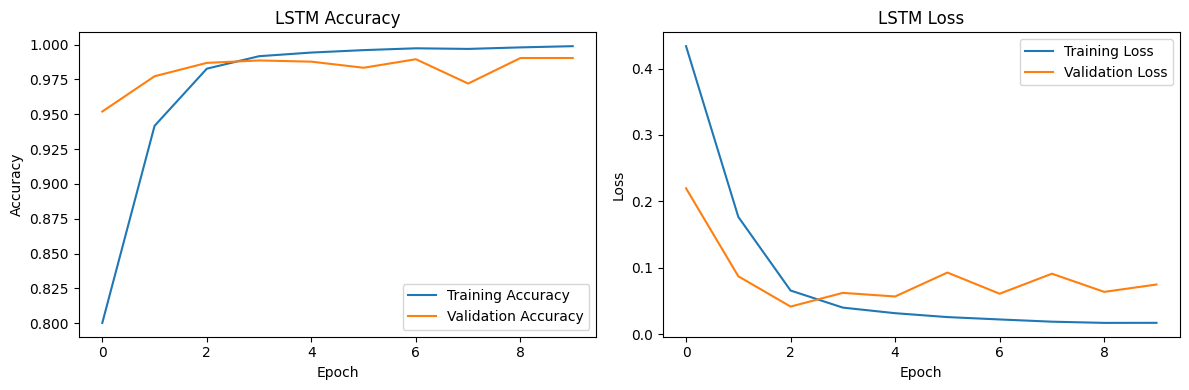

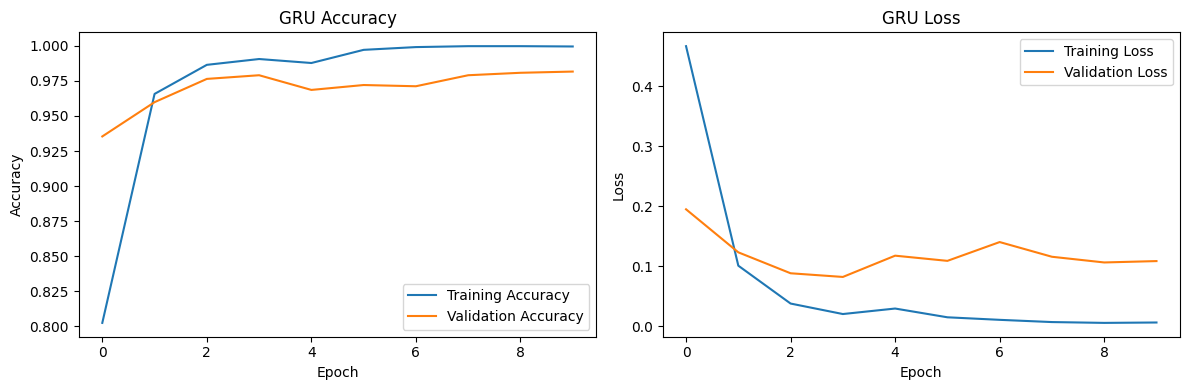




LSTM Test Accuracy: 0.9904
GRU Test Accuracy: 0.9817


In [48]:
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{model_name} Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{model_name} Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Plot results for LSTM and GRU
plot_history(history_lstm, 'LSTM')
plot_history(history_gru, 'GRU')

# Evaluate models on test set
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test, y_test, verbose=0)
gru_loss, gru_accuracy = gru_model.evaluate(X_test, y_test, verbose=0)

print('\n\n')
print(f"LSTM Test Accuracy: {lstm_accuracy:.4f}")
print(f"GRU Test Accuracy: {gru_accuracy:.4f}")

___
$$****************************$$
___

## Here we can not find any big difference between all models because the data is simple and we can find this difference in other complex data.

## Thanks